# The aim of this file is to preprocess the raw data from the csv file.

## First we install necessary imports


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import pathlib
import os

## load data


In [8]:
listing_data = pd.read_csv('raw_data/listings.csv')
images_data = pd.read_csv('raw_data/images.csv')

# EDA
- remove the lisitings with less than 5 images and remove images from images.csv


In [9]:
listing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5044 entries, 0 to 5043
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        5044 non-null   int64  
 1   url              5044 non-null   str    
 2   price_man_yen    5010 non-null   float64
 3   layout           4983 non-null   str    
 4   area_sqm         5036 non-null   float64
 5   year_built       5044 non-null   int64  
 6   floor_number     5036 non-null   float64
 7   floors_total     5036 non-null   float64
 8   address          5044 non-null   str    
 9   nearest_station  5030 non-null   str    
 10  walk_minutes     5030 non-null   float64
 11  image_count      5044 non-null   int64  
dtypes: float64(5), int64(3), str(4)
memory usage: 473.0 KB


In [10]:
images_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 95728 entries, 0 to 95727
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   source_id    95728 non-null  int64
 1   listing_url  95728 non-null  str  
 2   image_url    95728 non-null  str  
 3   image_name   95728 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.9 MB


In [11]:
listing_data.describe()

,source_id,price_man_yen,area_sqm,year_built,floor_number,floors_total,walk_minutes,image_count
count,5.044000e+03,5010.00000,5036.000000,5044.000000,5036.000000,5036.000000,5030.000000,5044.000000
mean,4.774988e+07,11798.38483,66.213459,1998.227795,7.939635,7.387212,7.584891,18.978588
std,2.923573e+07,12576.41180,21.982188,15.648284,8.545476,6.792936,4.671539,16.346399
min,2.000007e+07,420.00000,16.510000,1964.000000,1.000000,1.000000,1.000000,1.000000
25%,2.021120e+07,4998.00000,53.780000,1983.000000,3.000000,2.000000,4.000000,11.000000
50%,2.035363e+07,7998.00000,64.240000,2000.000000,5.000000,7.000000,7.000000,22.000000
75%,7.890249e+07,13999.00000,75.412500,2011.000000,9.000000,11.000000,10.000000,27.000000
max,7.923565e+07,216800.00000,383.640000,2026.000000,59.000000,58.000000,46.000000,805.000000


In [12]:
listing_data.shape

(5044, 12)

In [13]:
images_data.shape

(95728, 4)

In [14]:
listing_data.columns

Index(['source_id', 'url', 'price_man_yen', 'layout', 'area_sqm', 'year_built',
       'floor_number', 'floors_total', 'address', 'nearest_station',
       'walk_minutes', 'image_count'],
      dtype='str')

In [15]:
images_data.columns

Index(['source_id', 'listing_url', 'image_url', 'image_name'], dtype='str')

In [16]:
listing_data.source_id.nunique()

5044

In [17]:
images_data.source_id.nunique()

5044

In [18]:
listing_data.isna().any()

source_id          False
url                False
price_man_yen       True
layout              True
area_sqm            True
year_built         False
floor_number        True
floors_total        True
address            False
nearest_station     True
walk_minutes        True
image_count        False
dtype: bool

In [19]:
listing_data = listing_data.dropna()

In [20]:
listing_data

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
0,20143760,https://suumo.jp/ms/chuko/chiba/sc_ichikawa/nc...,5280.0,4LDK,77.31,2000,3.0,5.0,千葉県市川市新井３ [ ■ 周辺環境 ],南行徳駅,7.0,1
1,20143796,https://suumo.jp/ms/chuko/chiba/sc_ichikawa/nc...,3799.0,3LDK,66.00,2000,3.0,6.0,千葉県市川市広尾１ [ ■ 周辺環境 ],南行徳駅,17.0,1
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...
5037,78931650,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,137000.0,3LDK,214.98,2024,4.0,1.0,東京都渋谷区鉢山町 [ ■ 周辺環境 ],代官山駅,10.0,15
5038,79115894,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,2LDK,177.80,2025,2.0,4.0,東京都渋谷区西原３ [ ■ 周辺環境 ],代々木上原駅,5.0,21
5039,79136188,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,148800.0,3LDK,150.20,2024,4.0,2.0,東京都渋谷区神宮前６ [ ■ 周辺環境 ],明治神宮前駅,3.0,21
5041,20218899,https://suumo.jp/ms/chuko/tokyo/sc_taito/nc_20...,8180.0,2LDK,53.46,2019,13.0,13.0,東京都台東区三ノ輪２-2-1 [ ■ 周辺環境 ],三ノ輪駅,4.0,1


In [21]:
images_data.isna().any()

source_id      False
listing_url    False
image_url      False
image_name     False
dtype: bool

In [22]:
#keep only the listings that have 5 or more images
listing_data = listing_data[listing_data['image_count'] >= 5]
listing_data

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,2LDK,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27
7,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,2DK,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,10.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...
5035,78637031,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,118000.0,2LDK,106.76,2024,5.0,2.0,東京都渋谷区神宮前６ [ ■ 周辺環境 ],明治神宮前駅,3.0,21
5036,78783232,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,3LDK,152.01,2014,2.0,1.0,東京都渋谷区広尾３-12-17 [ ■ 周辺環境 ],広尾駅,12.0,15
5037,78931650,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,137000.0,3LDK,214.98,2024,4.0,1.0,東京都渋谷区鉢山町 [ ■ 周辺環境 ],代官山駅,10.0,15
5038,79115894,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,2LDK,177.80,2025,2.0,4.0,東京都渋谷区西原３ [ ■ 周辺環境 ],代々木上原駅,5.0,21


In [23]:
#remove the images of listings not being used
images_data = images_data[images_data['source_id'].isin(listing_data['source_id'])]
images_data


,source_id,listing_url,image_url,image_name
26,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_c236d31dd0.jpg
27,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_99ba43ab8d.jpg
28,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_10972b9e12.jpg
29,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_ec94786bdf.jpg
30,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_67727e9e7f.jpg
...,...,...,...,...
95694,79136188,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,79136188_b1dbe9dbb7.jpg
95695,79136188,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,79136188_72d5116bd1.jpg
95696,79136188,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,79136188_41f791b069.jpg
95697,79136188,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,79136188_cc820526ae.jpg


## Inspecting the distributions of columns in listings data.

### Price_man_yen

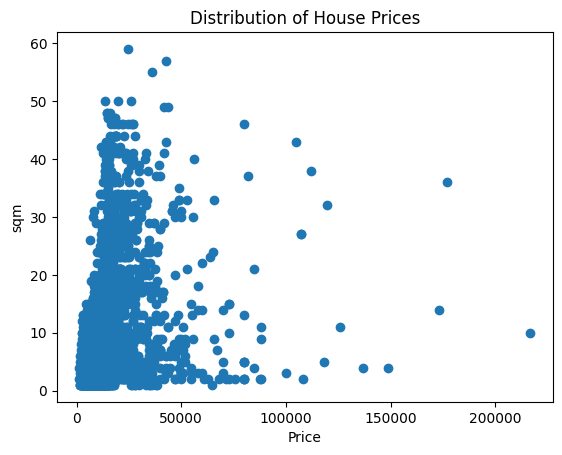

In [24]:
price = listing_data['price_man_yen']
sqm = listing_data['floor_number']
plt.scatter(price,sqm)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("sqm")
plt.show()

## delete folders from suumo_images that are no longer needed


In [25]:
# ids_to_delete = listing_data[listing_data['image_count'] < 5]['source_id']
# len(ids_to_delete)

In [26]:
# def delete_folder_by_name(source_id):
#     """
#     Deletes a folder and all its contents recursively.

#     Args:
#         folder_path (str or path-like object): The path to the folder to be deleted.
#     """
#     source_id = 0000
#     folder_path = f'raw_data/suumo_images/{source_id}'
#     if os.path.isdir(folder_path):
#         try:
#             # Recursively remove the directory and all its contents
#             shutil.rmtree(folder_path)
#             print(f"Directory '{folder_path}' has been removed successfully.")
#         except OSError as e:
#             print(f"Error: {folder_path} : {e.strerror}")
#     else:
#         print(f"Error: Directory '{folder_path}' not found or is not a directory.")